# LSTM sentiment classifier on Rotten Tomatoes
This notebook trains an LSTM-based binary sentiment classifier on the Rotten Tomatoes movie review dataset. It includes preprocessing, tokenization, model definition, training with validation and checkpointing, plots of validation loss/accuracy over epochs, and a final evaluation on the test set.

## Imports

In [2]:
import os
import math
import random
import numpy as np
from collections import Counter
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
debug = True
max_samples = 2000
vocab_size = 5000
max_len = 80
batch_size = 64
epochs = 3
embedding_dim = 64
hidden_dim = 64
num_workers = 0
import torch
torch.backends.cudnn.benchmark = True
print('Debug mode:', debug)
print('Quick-run settings: samples<=', max_samples, ', vocab<=', vocab_size, ', max_len=', max_len, ', batch_size=', batch_size, ', epochs=', epochs)

Debug mode: True
Quick-run settings: samples<= 2000 , vocab<= 5000 , max_len= 80 , batch_size= 64 , epochs= 3


## Load dataset and preprocessing

In [5]:
def preprocess_text(text):
    text = text.lower()
    text = __import__('re').sub(r'\W', ' ', text)
    text = __import__('re').sub(r'\s+', ' ', text)
    text = __import__('re').sub(r'\d', ' ', text)
    return text.strip()

ds = load_dataset('cornell-movie-review-data/rotten_tomatoes')
raw_texts = list(ds['train']['text'])
raw_labels = list(ds['train']['label'])
texts = [preprocess_text(t) for t in raw_texts]
labels = raw_labels

if 'test' in ds:
    test_texts = [preprocess_text(t) for t in ds['test']['text']]
    test_labels = list(ds['test']['label'])
else:
    test_texts = None
    test_labels = None

print('Loaded', len(texts), 'train samples')
if test_texts is not None:
    print('Loaded', len(test_texts), 'test samples')

Loaded 8530 train samples
Loaded 1066 test samples


## Tokenization, vocabulary and datasets

In [6]:
def simple_tokenize(s):
    return s.split()

all_tokens = []
for t in texts:
    all_tokens.extend(simple_tokenize(t))

vocab_size = 20000
counter = Counter(all_tokens)
most_common = counter.most_common(vocab_size - 2)
itos = ['<PAD>', '<UNK>'] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}
pad_idx = stoi['<PAD>']
unk_idx = stoi['<UNK>']

def encode(text, max_len=128):
    toks = simple_tokenize(text)[:max_len]
    ids = [stoi.get(w, unk_idx) for w in toks]
    if len(ids) < max_len:
        ids = ids + [pad_idx] * (max_len - len(ids))
    return ids

max_len = 128
X = [encode(t, max_len) for t in texts]
y = labels

if test_texts is not None:
    X_test = [encode(t, max_len) for t in test_texts]
    y_test = test_labels
else:
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
    X = X_train_full
    y = y_train_full

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print('Train size:', len(X_train), 'Val size:', len(X_val), 'Test size:', len(X_test))

Train size: 7677 Val size: 853 Test size: 1066


In [7]:
class RottenDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

batch_size = 128
train_ds = RottenDataset(X_train, y_train)
val_ds = RottenDataset(X_val, y_val)
test_ds = RottenDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print('Data loaders ready')

Data loaders ready


## Model definition (LSTM)

In [8]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, n_layers=1, bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, bidirectional=bidirectional, dropout=dropout if n_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
    def forward(self, x):
        emb = self.embedding(x)
        _, (hn, _) = self.lstm(emb)
        last = hn[-1]
        out = self.dropout(last)
        logits = self.fc(out).squeeze(1)
        return logits

vocab_size = len(itos)
model = LSTMSentiment(vocab_size, embed_dim=128, hidden_dim=128, n_layers=1, bidirectional=False, dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
print(model)

LSTMSentiment(
  (embedding): Embedding(16353, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


## Training loop with validation and checkpointing

In [9]:
def evaluate(model, loader, device):
    model.eval()
    losses = []
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs = torch.sigmoid(logits).cpu().numpy()
            batch_preds = (probs > 0.5).astype(int)
            preds.extend(batch_preds.tolist())
            trues.extend(yb.cpu().numpy().astype(int).tolist())
    acc = accuracy_score(trues, preds)
    return np.mean(losses), acc

epochs = 5
best_val_acc = 0.0
history = {'val_loss': [], 'val_acc': []}
checkpoint_path = 'best_rotten_lstm.pt'

for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
    val_loss, val_acc = evaluate(model, val_loader, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch+1,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc': val_acc
        }, checkpoint_path)
        print('Saved best checkpoint')

Epoch 1: val_loss=0.6931, val_acc=0.5006
Saved best checkpoint


Epoch 2: val_loss=0.6931, val_acc=0.4994


Epoch 3: val_loss=0.6933, val_acc=0.5006


Epoch 4: val_loss=0.6932, val_acc=0.5006


Epoch 5: val_loss=0.6932, val_acc=0.5006


## Plots: validation loss and accuracy over epochs

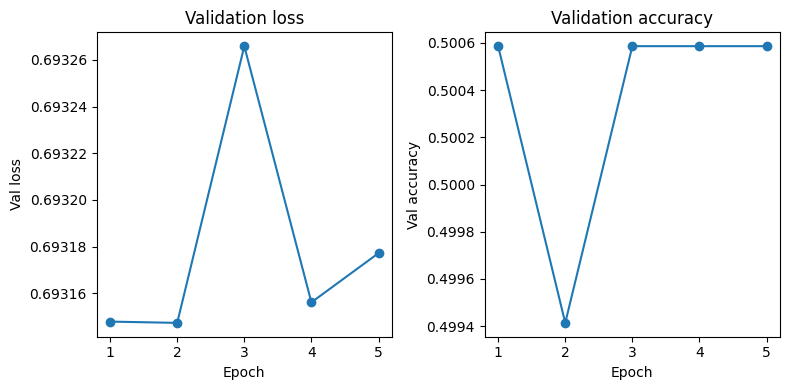

In [10]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.title('Validation loss')

plt.subplot(1,2,2)
plt.plot(range(1, len(history['val_acc'])+1), history['val_acc'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Val accuracy')
plt.title('Validation accuracy')
plt.tight_layout()
plt.show()

## Load best checkpoint and evaluate on test set

In [11]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Best checkpoint epoch={checkpoint.get('epoch')}, val_acc={checkpoint.get('val_acc'):.4f}')
print(f'Test loss={test_loss:.4f}, Test acc={test_acc:.4f}')

Best checkpoint epoch=1, val_acc=0.5006
Test loss=0.6931, Test acc=0.5000


## Analysis and suggestions
- If validation accuracy is low or the curve overfits, try: increasing dropout, using early stopping, or reducing model capacity.
- Try pretrained embeddings (GloVe or FastText) to give the model better starting representations.
- Increase the amount of training data or do data augmentation.
- Tune hyperparameters: learning rate, batch size, max sequence length, embedding and hidden sizes.
- Use bidirectional LSTM or add more layers if underfitting.
- Consider trying a CNN or transformer-based classifier for comparison.